<table align="left">
  <td>
    <a href="https://colab.research.google.com/drive/16E5w9aMNq43FK1BEDZi-cjJbxEkmmNXQ?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

**1. Load data**

In [9]:
# Load data
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

In [10]:
print('x_train shape',X_train_full.shape)
print('x_train Dtype',X_train_full.dtype)

x_train shape (60000, 28, 28)
x_train Dtype uint8


In [11]:
# We create a validation dataset and scale the input features since we are going work with gradient Descent

X_valid, X_train = X_train_full[:5000] / 255.0,  X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [12]:
# lets label the class names

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

**2. Build the DNN Model**

Create a model with five hidden layers, each having 100 neurons, using He initialization and the ELU activation function

In [32]:
# Build the DNN model
# Kernerl Intializer he_normal which helps prevent vanishing/exploding gradients during training.

def build_model():
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28, 28]), # Re- shape 2D image to 1D
        keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),  #Allows small negative outputs, avoiding dead neurons (common in ReLU).
        keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
        keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
        keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
        keras.layers.Dense(100, activation="elu", kernel_initializer="he_normal"),
        keras.layers.Dense(10, activation="softmax")  # Useful for multi-class classification
    ])
    return model

model = build_model()

In [33]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,910 (468.40 KB)

 Trainable params: 119,910 (468.40 KB)

 Non-trainable params: 0 (0.00 B)

**3. Compile the Model**

In [34]:
model.compile(optimizer=keras.optimizers.Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

**4. Setup Callbacks for Early Stopping**

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


**5. Train the Model**

In [45]:
history = model.fit(X_train,
                    y_train,
                    epochs=50,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping]
                    )

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8863 - loss: 0.3677 - val_accuracy: 0.9472 - val_loss: 0.1761
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9574 - loss: 0.1330 - val_accuracy: 0.9700 - val_loss: 0.1092
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9714 - loss: 0.0887 - val_accuracy: 0.9728 - val_loss: 0.0977
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9758 - loss: 0.0757 - val_accuracy: 0.9682 - val_loss: 0.1263
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9797 - loss: 0.0622 - val_accuracy: 0.9722 - val_loss: 0.0930
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9832 - loss: 0.0518 - val_accuracy: 0.9712 - val_loss: 0.0961
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9852 - loss: 0.0437 - val_accuracy: 0.9710 - val_loss: 0.1053
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0400 

In [46]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7474 - loss: 127.2293


[120.02867126464844, 0.7565000057220459]

**Add Batch Normalization and Retrain**

- Faster convergence and potentially better validation accuracy

In [22]:
# Updated Model with Batch Normalization

def create_model_with_bn():
    model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]), # Flatten the images
    keras.layers.BatchNormalization(),          # apply batch normalization

    keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False), #Helps maintain stable variance across layers to avoid vanishing gradients.
    keras.layers.BatchNormalization(),
    keras.layers.Activation("elu"),

    keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("elu"), #Exponential Linear Unit (ELU) is better than ReLU in deep networks because it avoids dying neurons by allowing small negative values.
    keras.layers.Dense(10, activation="softmax")
])
    return model


In [24]:
# Create and compile the model with Batch Normalization
model_bn = create_model_with_bn()


model_bn.compile(optimizer=keras.optimizers.Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
history_bn = model_bn.fit(X_train,
                    y_train,
                    epochs=50,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping]
                    )

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8812 - loss: 0.3896 - val_accuracy: 0.9528 - val_loss: 0.1613
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9523 - loss: 0.1539 - val_accuracy: 0.9618 - val_loss: 0.1333
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9665 - loss: 0.1084 - val_accuracy: 0.9628 - val_loss: 0.1122
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9726 - loss: 0.0875 - val_accuracy: 0.9714 - val_loss: 0.1040
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9757 - loss: 0.0717 - val_accuracy: 0.9702 - val_loss: 0.1147
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9801 - loss: 0.0598 - val_accuracy: 0.9692 - val_loss: 0.1058
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9820 - loss: 0.0553 - val_accuracy: 0.9756 - val_loss: 0.0980
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9833 - loss: 0.

In [26]:
model_bn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8016 - loss: 57.3892


[52.4775390625, 0.8191999793052673]

**Add Batch Normalization and Drop Out**

-Reduces overfitting, resulting in a smaller gap between training and validation accuracy.

In [28]:
def create_model_with_bn_and_dropout():
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28, 28]),  # Flatten input images
        keras.layers.BatchNormalization(),           # Batch normalization

        keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("elu"),
        keras.layers.Dropout(0.3),  # Dropout with 30% rate to prevent overfitting

        keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.Activation("elu"),
        keras.layers.Dropout(0.3),  # Dropout in the second hidden layer

        keras.layers.Dense(10, activation="softmax")  # Output layer for 10 classes
    ])
    return model

# Create the model
model_with_bn_dropout = create_model_with_bn_and_dropout()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
# Compile the model
model_with_bn_dropout.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [30]:
model_with_bn_dropout.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 784)                 │           3,136 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 300)                 │         235,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 100)                 │          30,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 100)                 │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 270,946 (1.03 MB)

 Trainable params: 268,578 (1.02 MB)

 Non-trainable params: 2,368 (9.25 KB)

In [ ]:
model_with_bn_dropout.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [31]:
history_with_bn_dropout= model_with_bn_dropout.fit(X_train,
                    y_train,
                    epochs=50,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping]
                    )

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8384 - loss: 0.5143 - val_accuracy: 0.9414 - val_loss: 0.2007
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9219 - loss: 0.2590 - val_accuracy: 0.9520 - val_loss: 0.1575
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9392 - loss: 0.1974 - val_accuracy: 0.9642 - val_loss: 0.1292
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9443 - loss: 0.1799 - val_accuracy: 0.9632 - val_loss: 0.1317
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9512 - loss: 0.1558 - val_accuracy: 0.9668 - val_loss: 0.1217
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9566 - loss: 0.1407 - val_accuracy: 0.9690 - val_loss: 0.1173
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9590 - loss: 0.1295 - val_accuracy: 0.9692 - val_loss: 0.1182
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9607 - loss: 0

**Visualizing Learning Curves: Loss and Accuracy**

In [38]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, label):
    # Plot training & validation loss
    plt.plot(history.history['loss'], label=f'{label} - Train Loss')
    plt.plot(history.history['val_loss'], label=f'{label} - Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.figure()
    # Plot training & validation accuracy
    plt.plot(history.history['accuracy'], label=f'{label} - Train Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{label} - Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

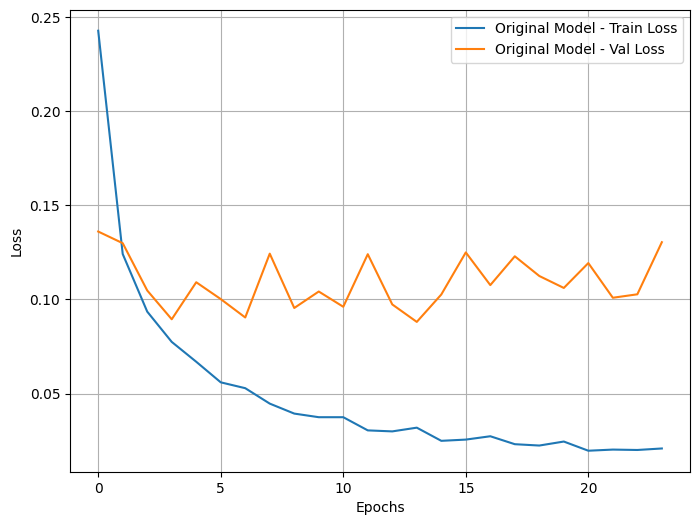

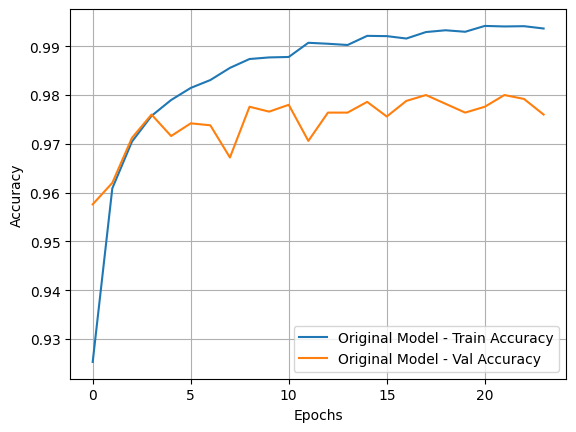

In [41]:
# Plot learning curves for the models
plt.figure(figsize=(8, 6))
plot_learning_curves(history, "Original Model")



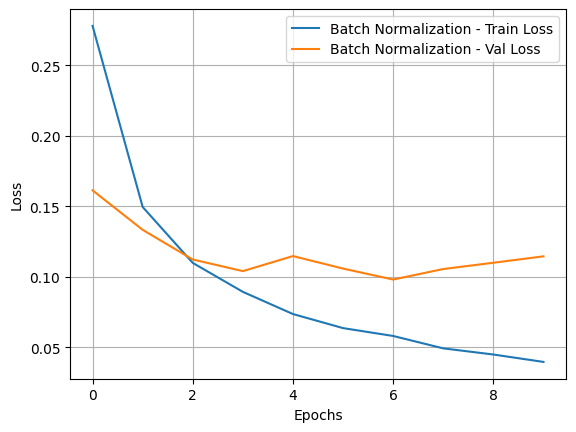

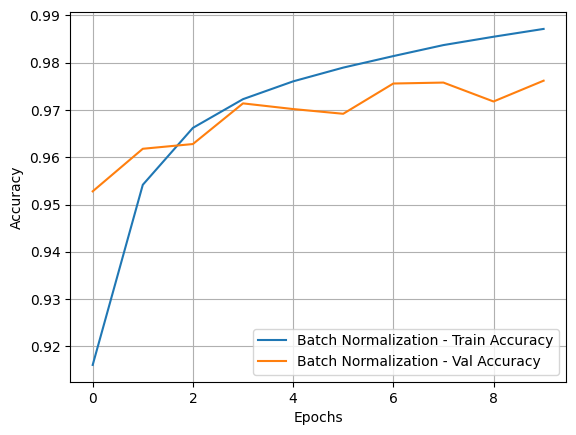

In [42]:
plot_learning_curves(history_bn, "Batch Normalization")

**Faster Convergence:**
Batch Normalization should reduce the number of epochs required to reach the same validation accuracy compared to the original model.

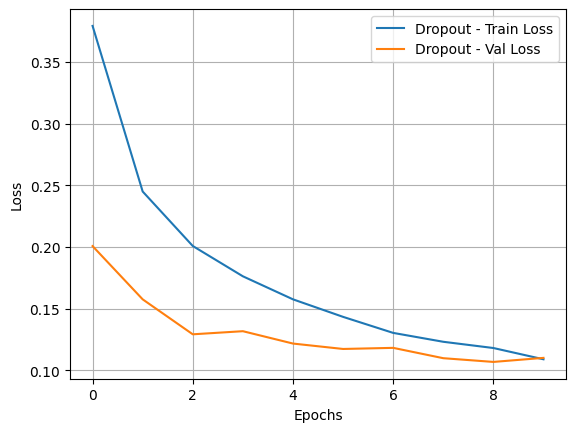

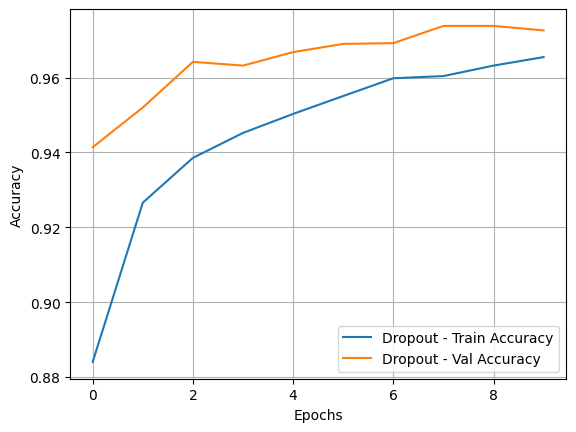

In [44]:
plot_learning_curves(history_with_bn_dropout, "Dropout")

**Overfitting Signs:** Dropout  reduce this gap by forcing the model to generalize better.